<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/HepatitisC_deeplearninig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hepatitis C Classification deeplearning

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

In [4]:
df = pd.read_csv("HepatitisCdata1.csv")

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
Category,0
Age,0
Sex,0
ALB,1
ALP,18
ALT,1
AST,0
BIL,0
CHE,0


In [13]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Category'] = le.fit_transform(df['Category'])

In [14]:
for index,i in enumerate(df.columns):
  if index ==3:
    df[i].fillna(df[i].mode()[0],inplace=True)
  else:
    df[i].fillna(df[i].mean(),inplace=True)

/tmp/ipykernel_1422/4210722997.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(),inplace=True)
/tmp/ipykernel_1422/4210722997.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [15]:
df

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0,32,1,38.5,52.50000,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0,32,1,38.5,70.30000,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0,32,1,46.9,74.70000,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0,32,1,43.2,52.00000,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0,32,1,39.2,74.10000,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,611,4,62,0,32.0,416.60000,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
611,612,4,64,0,24.0,102.80000,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3
612,613,4,64,0,29.0,87.30000,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82.0
613,614,4,46,0,33.0,68.28392,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71.0


In [16]:
X = df.drop(columns=['Unnamed: 0','Category'],axis=1)
Y = df['Category']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(12,)),
    keras.layers.Dense(24,activation='relu'),
    keras.layers.Dense(5,activation='sigmoid')
])

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(X_train,Y_train,validation_split=0.1,epochs=30)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6131 - loss: 1.2065 - val_accuracy: 0.6600 - val_loss: 1.1417
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7715 - loss: 1.0456 - val_accuracy: 0.7600 - val_loss: 1.0002
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8439 - loss: 0.9115 - val_accuracy: 0.8600 - val_loss: 0.8798
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8824 - loss: 0.7979 - val_accuracy: 0.8800 - val_loss: 0.7818
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8982 - loss: 0.7049 - val_accuracy: 0.9000 - val_loss: 0.7006
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9027 - loss: 0.6284 - val_accuracy: 0.9000 - val_loss: 0.6348
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9072 - loss: 0.5645 - val_accuracy: 0.9000 - val_loss: 0.5798
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9118 - loss: 0.5129 - val_accuracy: 0.9000 - val_loss

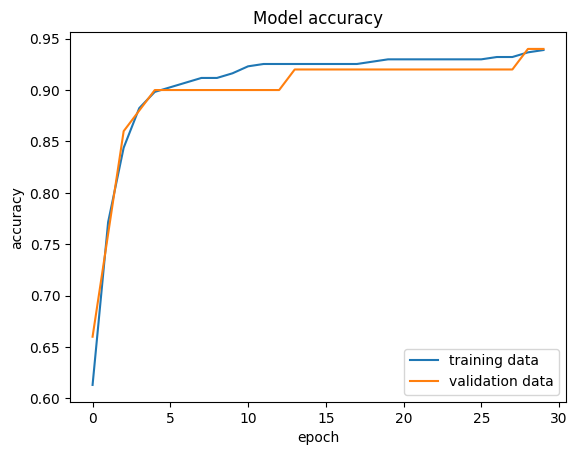

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='lower right')

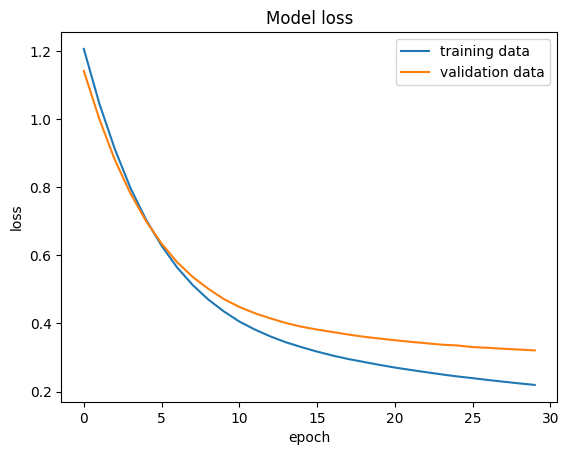

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='upper right')

In [33]:
loss, accuracy = model.evaluate(X_test,Y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8211 - loss: 0.6139
0.8211382031440735


In [34]:
Y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [35]:
Y_pred_max = np.argmax(Y_pred)
print(Y_pred_max)

130


In [36]:
input_data =[[62,0,32.0,416.60000,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5]]
input_num_arr = np.asarray(input_data)
input_num_arr_reshaped = input_num_arr.reshape(1,-1)
input_num_arr_scaled = scaler.transform(input_num_arr_reshaped)
prediction = model.predict(input_num_arr_scaled)
prediction_max = np.argmax(prediction)
print(prediction_max)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
